<a href="https://colab.research.google.com/github/Angappan95/langchain-practice/blob/main/06_workflow_with_traces.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install langchain langgraph python-dotenv notebook langchain-google-genai langsmith

In [2]:
import os
from google.colab import userdata

os.environ["LANGSMITH_TRACING"] = "true"
os.environ["LANGSMITH_ENDPOINT"] = "https://api.smith.langchain.com"
os.environ["LANGSMITH_PROJECT"] = "practice"
os.environ["LANGSMITH_API_KEY"] = userdata.get('LANGSMITH_API_KEY')

In [77]:
from google.colab import userdata
GOOGLE_API_KEY = userdata.get('GOOGLE_API_KEY')

from langchain.chat_models import init_chat_model

try:
  llm = init_chat_model("google_genai:gemini-3.1-flash-lite-preview", google_api_key=GOOGLE_API_KEY)
except Exception as e:
  print(f"Unable to load Gemini model {e}")

In [78]:
from typing import TypedDict
from langgraph.graph.message import Annotated, add_messages

class State(TypedDict):
  messages: Annotated[list, add_messages]

In [79]:
from langchain_core.tools import tool
from langgraph.prebuilt import ToolNode, tools_condition

@tool
def get_stock_price(stock: str):
    """
    Return the current stock price for the given ticker
    """
    stock_prices = {
        "HDFC": "45.00",
        "SBIN": "37.85",
        "ONGC": "84.25",
        "INFY": "100",
        "TCS": "102",
        "BEL": "98"
    }
    return stock_prices.get(stock, "NA")

In [80]:
tools = [get_stock_price]
tool_node = ToolNode(tools)

In [81]:
def chatbot(state: State):
    return {"messages": [llm.invoke(state['messages'],tools=tools)]}

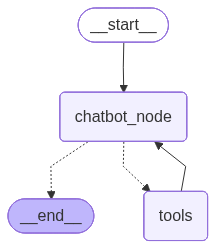

In [82]:
from langgraph.graph import StateGraph
from langgraph.graph.state import START, END
from langgraph.checkpoint.memory import MemorySaver

memory = MemorySaver()

builder = StateGraph(State)
builder.add_node('chatbot_node', chatbot)
builder.add_node('tools', tool_node)

builder.add_edge(START, 'chatbot_node')
builder.add_conditional_edges('chatbot_node', tools_condition)
builder.add_edge('tools', 'chatbot_node')
builder.add_edge('chatbot_node', END)

workflow = builder.compile(checkpointer=memory)
workflow

In [83]:
from langsmith import traceable

@traceable
def ask_question(query, thread_id='0'):
    config = {'configurable': {'thread_id': thread_id}}
    state = workflow.invoke({'messages': [query]}, config=config)
    # print(state['messages'][-1].content[-1]['text'])
    return state

In [84]:
state105 = ask_question("You are an intelligent assistant. You should use only the provided tools. You should not assume things outside and do not use tools outside what is provided to you. What is the cost of 10 qtys of SBIN and 5 qtys of BEL. Explain the calculation step by step", '105')

In [85]:
print(state105['messages'][-1].content[-1]['text'])

To calculate the total cost for 10 quantities of SBIN and 5 quantities of BEL, we first determine the current price of each stock and then perform the multiplication and addition.

**Step 1: Get the current prices**
*   Current price of SBIN: **37.85**
*   Current price of BEL: **98.00**

**Step 2: Calculate the cost for each stock**
*   Cost for 10 SBIN: 10 * 37.85 = **378.50**
*   Cost for 5 BEL: 5 * 98.00 = **490.00**

**Step 3: Calculate the total cost**
*   Total cost = 378.50 + 490.00 = **868.50**

The total cost for 10 quantities of SBIN and 5 quantities of BEL is **868.50**.


In [87]:
state105_2 = ask_question("Add another 10 qtys of ONGC and 2 qts of TATAMOTORS", '105')
print(state105_2['messages'][-1].content[-1]['text'])

I have retrieved the price for ONGC, but unfortunately, I am unable to retrieve a valid price for TATAMOTORS.

Here is the step-by-step calculation for the new additions based on the available information:

**Step 1: Get the current prices**
*   Current price of ONGC: **84.25**
*   Current price of TATAMOTORS: **Not Available**

**Step 2: Calculate the cost for the new additions**
*   Cost for 10 ONGC: 10 * 84.25 = **842.50**
*   Cost for 2 TATAMOTORS: Unable to calculate due to missing price data.

**Summary:**
*   Previous total (SBIN + BEL): **868.50**
*   Cost of 10 ONGC: **842.50**
*   Cost of 2 TATAMOTORS: **N/A**

Because the price for TATAMOTORS could not be retrieved, I cannot provide a final grand total at this time.


In [88]:
state105_3 = ask_question("Whats the total cost so far", "105")
print(state105_3['messages'][-1].content[-1]['text'])

Based on the information retrieved so far, here is the breakdown of the total cost for the items we have successfully priced:

**Step 1: Breakdown of costs for priced items**
*   **10 SBIN:** 10 * 37.85 = 378.50
*   **5 BEL:** 5 * 98.00 = 490.00
*   **10 ONGC:** 10 * 84.25 = 842.50

**Step 2: Calculate the sub-total**
*   Sub-total = 378.50 + 490.00 + 842.50 = **1,711.00**

**Conclusion:**
The total cost for the quantities of SBIN, BEL, and ONGC is **1,711.00**. Please note that this total **does not include** the cost for the 2 units of TATAMOTORS, as their price remains unavailable.
